`23/09/2026`

# Test of dynamics implemenetation

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from emerald.classical.dynamics import Dynamics, Trajectory
from emerald.fields import SinusoidField
from emerald.integrators import ScipyIntegrator
from emerald.potentials.msc import MorseSoftCoulomb
from emerald.potentials.soft_coulomb import SoftCoulomb


In [10]:
integ = ScipyIntegrator(method="RK45", rtol=1e-9, atol=1e-12)
field = SinusoidField(amplitude=0.4, ang_frequency=0.8, phase=0.0)

msc = MorseSoftCoulomb(alpha=0.5)
sc = SoftCoulomb(alpha=0.5)

fld_period = 2 * np.pi / field.ang_frequency
500/fld_period

63.66197723675813

In [11]:
from scipy.interpolate import interp1d

E = -0.5
rm, rM = msc.turning_points(E)
angs = msc.angle(E, np.linspace(rm, rM, 150))

# create a set of 100 angles between 0 and 2*pi and compute the corresponding positions and momenta
angles = np.linspace(0, 2 * np.pi, 150)

pos = interp1d(angs, np.linspace(rm, rM, 150), kind='cubic', fill_value="extrapolate")(angles)
mom = msc.momentum(E, pos)

states0 = np.column_stack((pos, mom))
# add the negative momenta values
states0 = np.vstack((states0, np.column_stack((pos, -mom))))

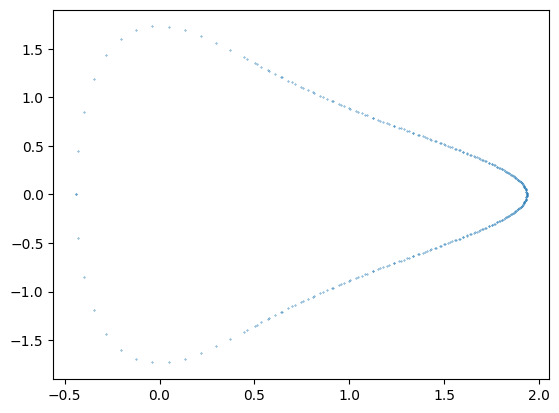

In [12]:
plt.scatter(*states0.T, s=0.1)

In [13]:
states0.shape

(300, 2)

In [14]:
dyn = Dynamics(potential=msc, field=field)

traj = integ.propagate(dyn, state0=states0, t_span=[0.0, 500.0], t_eval=np.arange(0.0, 60*fld_period, fld_period))

/media/gabriel/AcerD/Documentos/cursos/IC/Morse-Coulomb/Dev/src/emerald/potentials/msc.py:33: RuntimeWarning: overflow encountered in exp
  morse = 2*self.well_depth*self.beta*np.exp( -2*self.beta*r)*( np.exp( self.beta*r ) - 1 )
/media/gabriel/AcerD/Documentos/cursos/IC/Morse-Coulomb/Dev/src/emerald/potentials/msc.py:33: RuntimeWarning: invalid value encountered in multiply
  morse = 2*self.well_depth*self.beta*np.exp( -2*self.beta*r)*( np.exp( self.beta*r ) - 1 )


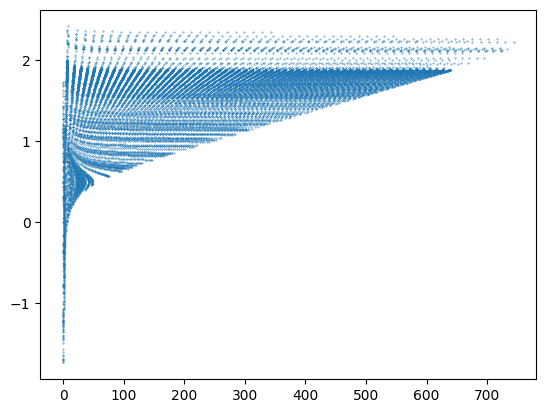

In [15]:
plt.scatter(traj.position, traj.momentum, s=0.1)
# plt.xlim(2*rm, 2*rM)

In [16]:
traj.ionization_probability()

0.9933333333333333

In [12]:
last_Es = traj.energy[-1, ...]

In [15]:
np.where(last_Es > 0)

(array([ 59,  67,  68,  69,  70, 157, 172, 173, 183, 196, 197, 206, 214,
        215, 217, 229, 230, 239, 240, 241, 245, 254, 255, 256, 259, 269,
        272, 276, 277, 281, 282, 284, 286, 290, 297, 298]),)

In [14]:
np.sum(last_Es > 0)

36

In [9]:
36/300

0.12

In [8]:
traj.N_trajectories

300

(-0.5, 0.0)

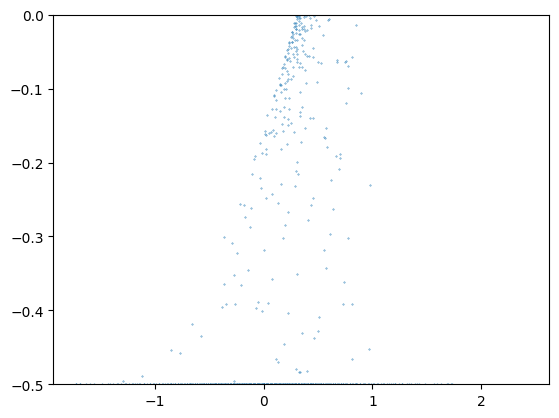

In [18]:
plt.scatter(traj.momentum, traj.energy, s=0.1)
plt.ylim(-0.5, 0)

(0.78, 0.785)

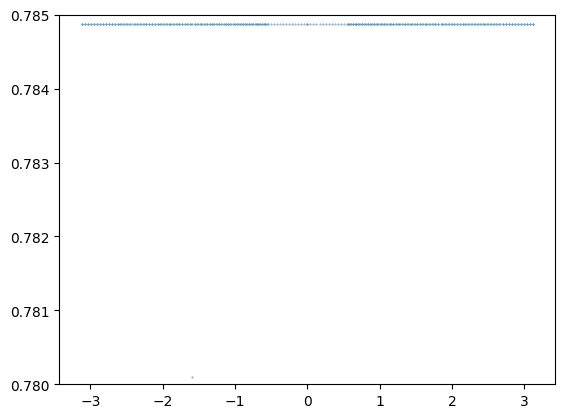

In [21]:
plt.scatter(traj.angle, traj.action, s=0.1)
plt.ylim(0.78, 0.785)

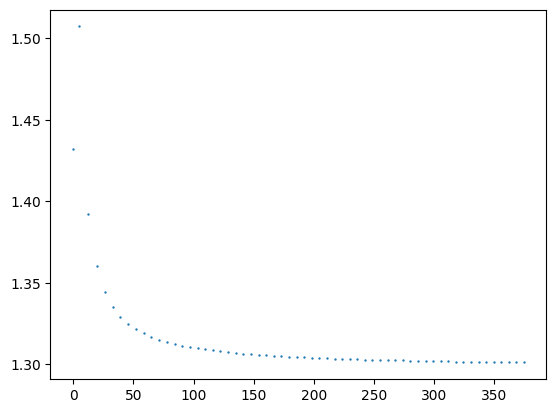

In [22]:
traj4 = traj.for_particle(4)

plt.scatter(traj4.position, traj4.momentum, s=0.5)

In [38]:
field.amplitude = 0.8

In [39]:
dyn_sc = Dynamics(sc, field)
integ = ScipyIntegrator(rtol=1e-10, atol=1e-14)
traj_sc = integ.propagate(dyn_sc, state0=states0, t_span=[0.0, 500.0], t_eval=np.arange(0.0, 60*fld_period, fld_period))

(-3.0, 3.0)

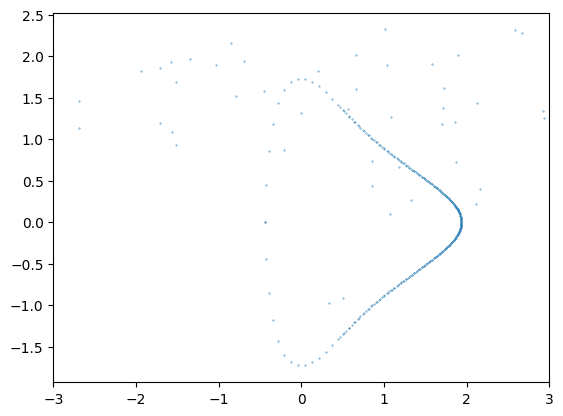

In [40]:
plt.scatter(traj_sc.position, traj_sc.momentum, s=0.1)
plt.xlim(-3, 3)

In [28]:
field.amplitude = 0.01

(0.55, 1.5)

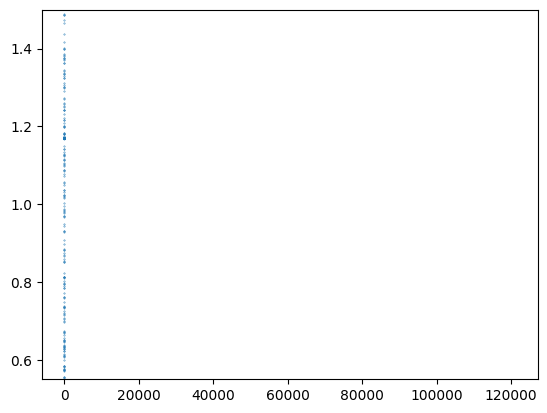

In [25]:
plt.scatter(np.sign(traj_sc.momentum)*traj_sc.angle, traj_sc.action, s=0.1)
plt.ylim(0.55, 1.5)

In [41]:
traj_sc.ionization_probability()

0.93

In [17]:
traj_sc.energy.shape

(60, 300)

In [12]:
fld = SinusoidField(0.1, 0.8, 0)
traj_weak = integ.propagate(Dynamics(sc, fld), [1, 1.e-3], (0, 100), np.linspace(0, 100, 1000))

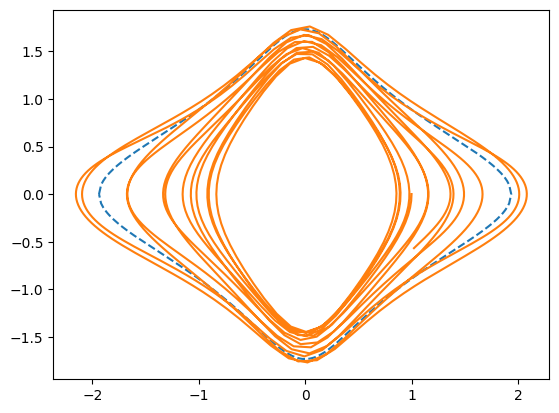

In [13]:
plt.plot(*sc.phase_space(-0.5, N=200), ls='--')
plt.plot(traj_weak.position, traj_weak.momentum)

(0.0, 24.0)

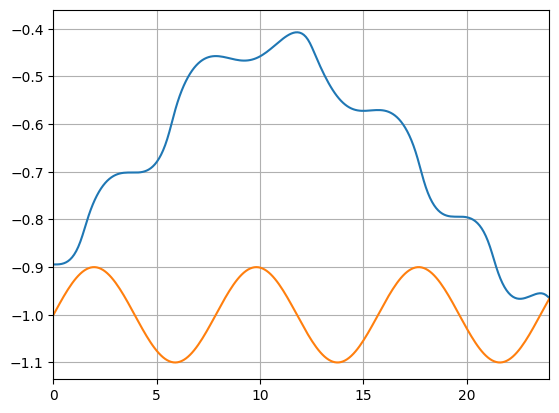

In [14]:
plt.plot(traj_weak.time, traj_weak.energy)
plt.plot(traj_weak.time, -1+fld(traj_weak.time))
plt.grid()
plt.xlim(0, 24)

In [20]:
traj_test = traj_weak.for_particle(1)

traj.states.ndim
traj.states.shape[1]

300

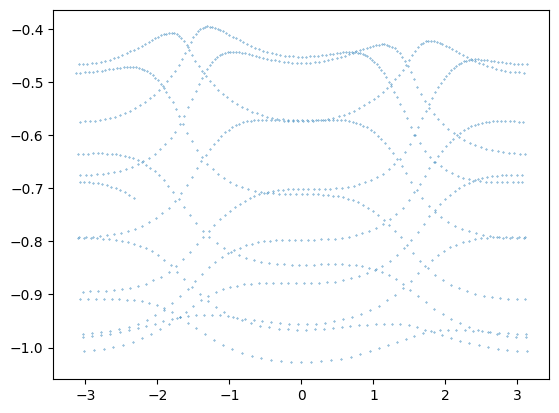

In [54]:
plt.scatter(np.sign(traj_weak.momentum)*traj_weak.angle, traj_weak.energy, s=0.1)

In [55]:
np.isnan(np.sign(traj_weak.momentum)*traj_weak.angle)

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,

In [56]:
(np.sign(traj_weak.momentum)*traj_weak.angle)[0]
np.sign(traj_weak.momentum)[0], traj_weak.angle[0]

(1.0, inf)

In [22]:
traj_weak.angle.shape

(1000,)

In [23]:
traj_weak.action.shape

(1000,)

In [24]:
E0 = traj_weak.energy[0]

In [26]:
sc.period(E0), 2*np.pi/fld.ang_frequency

(6.000818980348996, 7.853981633974483)

In [46]:
traj.energy.shape

(60, 300)

In [ ]:
field()

0.01

In [57]:
field.amplitude, field.ang_frequency

(0.01, 0.8)

In [64]:
field(traj.time)

array([ 0.00000000e+00, -2.44929360e-18, -4.89858720e-18, -7.34788079e-18,
       -9.79717439e-18,  2.32806688e-17, -1.46957616e-17, -1.71450552e-17,
       -1.95943488e-17,  4.90106312e-17,  4.65613376e-17,  4.41120440e-17,
       -2.93915232e-17,  3.92134568e-17, -3.42901104e-17,  3.43148696e-17,
       -3.91886976e-17,  2.94162824e-17,  9.80212624e-17,  2.45176952e-17,
        9.31226752e-17,  1.96191080e-17,  8.82240880e-17,  1.56829068e-16,
       -5.87830464e-17,  9.82193362e-18,  7.84269136e-17, -1.37185201e-16,
       -6.85802208e-17,  2.47592255e-20,  6.86297392e-17,  1.37234719e-16,
       -7.83773951e-17, -2.93989509e-16,  5.88325648e-17, -1.56779550e-16,
        1.96042525e-16, -1.95695896e-17,  4.90353904e-17, -1.66576724e-16,
        1.86245350e-16, -3.13583858e-16,  3.92382160e-17, -1.76373898e-16,
        1.76448176e-16, -3.91639383e-17,  3.13658136e-16,  9.80460216e-17,
       -1.17566093e-16,  2.35255982e-16,  1.96438672e-17,  3.72465942e-16,
        1.56853827e-16, -

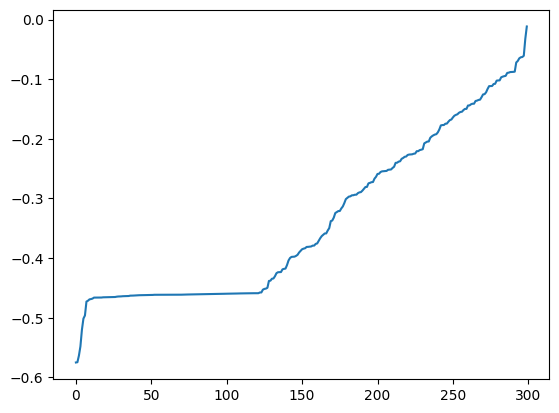

In [78]:
plt.plot(np.arange(300), np.sort(np.mean(traj.energy, axis=0)))
# plt.plot(traj.time, field(traj.time+fld_period/4)/field.amplitude)

In [30]:
np.sign(traj.momentum)*traj.angle

array([[ 0.        ,  0.0421534 ,  0.08433858, ..., -0.6057883 ,
        -0.58250576, -0.5596232 ],
       [ 1.45279785,  1.46909691,  1.4840238 , ...,  0.8201392 ,
         0.86146544,  0.90076468],
       [ 2.81001283,  2.77058592,  2.73078375, ...,  3.09417984,
         3.09999429,  3.10399275],
       ...,
       [ 0.56583061,  2.29321995,  0.52666824, ...,         nan,
                nan,  2.83038726],
       [ 0.60002381,  1.2149015 ,  0.59968153, ...,         nan,
                nan,  3.00614082],
       [ 0.6358254 ,  0.10784995,  0.67406266, ...,         nan,
                nan, -3.03915037]])

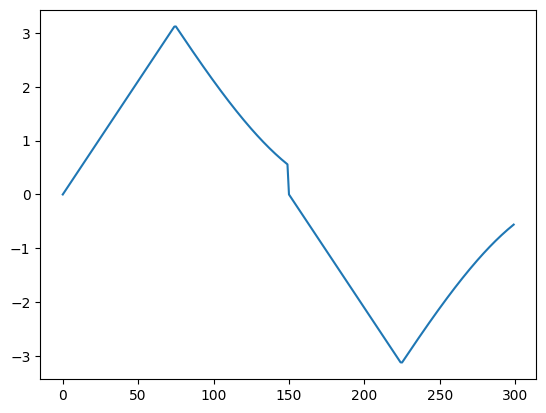

In [31]:
plt.plot((np.sign(traj.momentum)*traj.angle)[0])